In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn          as sns

In [3]:
customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")

In [4]:
for nome, df in {'orders':orders, 'reviews':reviews, 'customers': customers, 'items':items}.items():
    print(f"\n── {nome} ──")
    print(f"Shape: {df.shape}")
    print(df.isnull().sum())


── orders ──
Shape: (99441, 8)
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

── reviews ──
Shape: (99224, 7)
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

── customers ──
Shape: (99441, 5)
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

── items ──
Shape: (112650, 7)
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price              

In [5]:
# Filtrar apenas os pedidos que foram entregues
orders = orders[orders["order_status"] == "delivered"]
orders = orders.dropna(subset=["order_delivered_customer_date"])

In [6]:
# Converter coluna de data em datetime
date_cols = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print(f"\nPedidos entregues: {orders.shape[0]:,}")
print(orders[date_cols].dtypes)


Pedidos entregues: 96,470
order_purchase_timestamp         datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [7]:
# Agregar itens por pedido
items_agg = items.groupby("order_id").agg(
    frete_total=('freight_value', 'sum'),
    preco_total=('price', 'sum')
).reset_index()

In [8]:
# Juntar as tabelas
df = (orders
      .merge(reviews, how="inner", on="order_id")
      .merge(customers, how="inner", on="customer_id")
      .merge(items_agg, how="left", on="order_id"))

print(f"Data Frame final:{df.shape}")

Data Frame final:(96353, 20)


In [9]:
# Calculando os dias entre a compra e a entrega
df["tempo_entrega_dias"] = (
    df["order_delivered_customer_date"] -
    df["order_purchase_timestamp"]
).dt.days

In [10]:
# Verificar se atrasou em relação a estimativa
df["atrasou"] = (
    df["order_delivered_customer_date"] >
    df["order_estimated_delivery_date"]
).astype(int)   # Aqui transformei booleano em inteiro / 1 significa que atrasou e 0 que estava no prazo

In [11]:
# Dias de atraso
df["dias_atraso"] = (
    df["order_delivered_customer_date"] -
    df["order_estimated_delivery_date"]
).dt.days

In [12]:
# Faixa de tempo de entrega
df["faixa_entrega"] = pd.cut(
    df["tempo_entrega_dias"],
    bins=[0, 7, 14, 21, 30, 999],
    labels=["Até 7d", "8–14d", "15–21d", "22–30d", "+30d"]
)

In [13]:
print(df[["tempo_entrega_dias", "atrasou",
           "dias_atraso", "faixa_entrega"]].describe())

       tempo_entrega_dias       atrasou   dias_atraso
count        96353.000000  96353.000000  96353.000000
mean            12.058472      0.079914    -11.916806
std              9.462698      0.271162     10.112261
min              0.000000      0.000000   -147.000000
25%              6.000000      0.000000    -17.000000
50%             10.000000      0.000000    -12.000000
75%             15.000000      0.000000     -7.000000
max            208.000000      1.000000    188.000000


In [14]:
# Correlação de Pearson
r, p = stats.pearsonr(df["tempo_entrega_dias"], df["review_score"])
print(f"Correlação: {r:.3f} | p-valor: {p:.4f}")

Correlação: -0.334 | p-valor: 0.0000


In [15]:
# Nota por faixa de entrega 
nota_por_faixa = (df
    .groupby("faixa_entrega", observed=True)["review_score"]
    .agg(["mean","count"])
    .rename(columns={"mean":"nota_media", "count":"total"})
    .round(2)
)

print(nota_por_faixa)

               nota_media  total
faixa_entrega                   
Até 7d               4.41  33670
8–14d                4.29  36395
15–21d               4.10  15381
22–30d               3.49   6863
+30d                 2.18   4031


In [16]:
# Faixa de frete
df["faixa_frete"] = pd.cut(
    df["frete_total"],
    bins=[0, 13.84, 17.16, 23.99, float("inf")],
    labels = ["Barato (0-13)", "Moderado (13-17)", "Alto (17-24)", "Muito alto (24+)"]
)

In [17]:
# Nota por faixa de frete
nota_por_faixa_frete = (df
    .groupby("faixa_frete", observed=True)["review_score"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "nota_media", "count": "total"})
    .round(2)
)

print(nota_por_faixa_frete)

                  nota_media  total
faixa_frete                        
Barato (0-13)           4.31  23777
Moderado (13-17)        4.19  24086
Alto (17-24)            4.17  24069
Muito alto (24+)        3.94  24086


C:\Users\Gabriel\AppData\Local\Temp\ipykernel_4932\167617320.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("faixa_entrega")["review_score"]


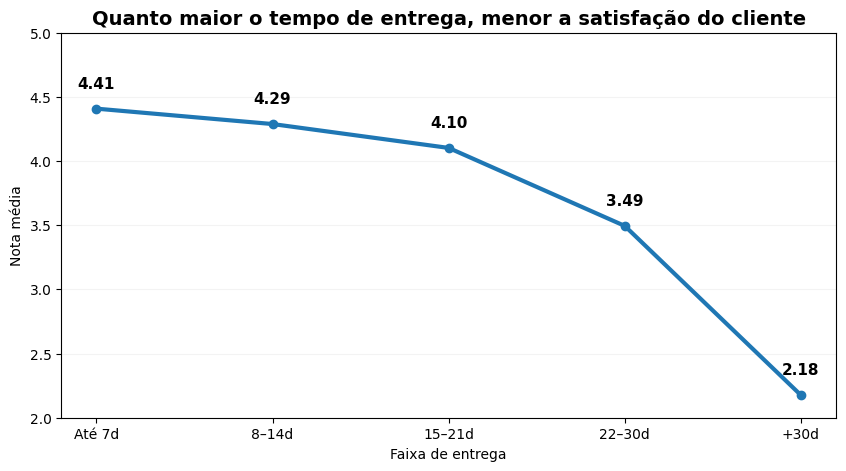

In [60]:
ordem_entrega = ["Até 7d", "8–14d", "15–21d", "22–30d", "+30d"]

dados = (
    df.groupby("faixa_entrega")["review_score"]
    .mean()
    .reindex(ordem_entrega)
)

plt.figure(figsize=(10, 5))
plt.plot(dados.index, dados.values, marker="o", linewidth=3)

for x, y in zip(dados.index, dados.values):
    plt.text(
        x,
        y + 0.16,
        f"{y:.2f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title("Quanto maior o tempo de entrega, menor a satisfação do cliente", fontsize=14, weight="bold")
plt.xlabel("Faixa de entrega")
plt.ylabel("Nota média")
plt.ylim(2, 5)
plt.grid(axis="y", alpha=0.15)
plt.grid(axis="x", visible=False)


C:\Users\Gabriel\AppData\Local\Temp\ipykernel_4932\3911288866.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("faixa_frete")["review_score"]


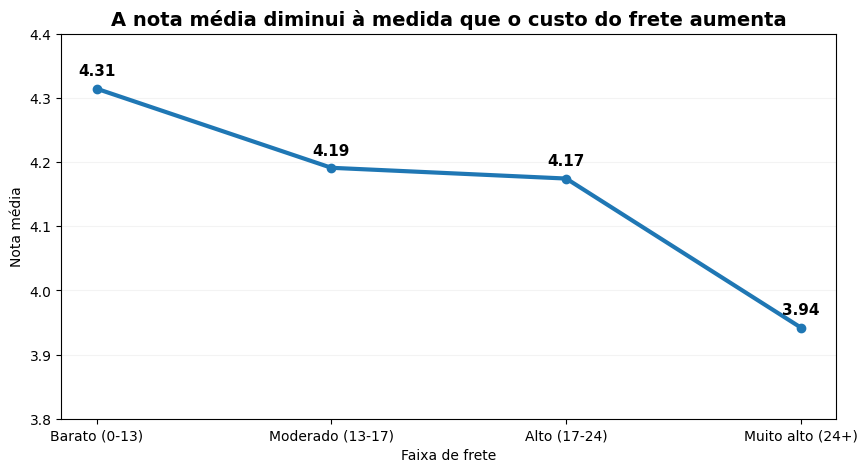

In [55]:
ordem_frete = ["Barato (0-13)", "Moderado (13-17)", "Alto (17-24)", "Muito alto (24+)"]

dados = (
    df.groupby("faixa_frete")["review_score"]
    .mean()
    .reindex(ordem_frete)
)

plt.figure(figsize=(10, 5))
plt.plot(dados.index, dados.values, marker="o", linewidth=3)

for x, y in zip(dados.index, dados.values):
    plt.text(
        x,
        y + 0.02,
        f"{y:.2f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title("A nota média diminui à medida que o custo do frete aumenta", fontsize=14, weight="bold")
plt.xlabel("Faixa de frete")
plt.ylabel("Nota média")
plt.ylim(3.8, 4.4)
plt.grid(axis="y", alpha=0.15)
plt.grid(axis="x", visible=False)


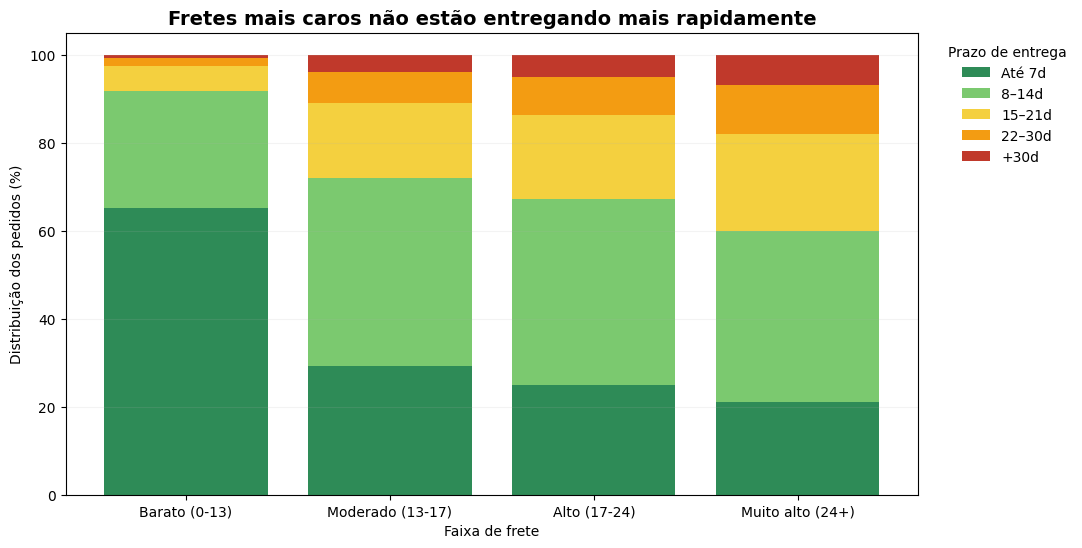

In [61]:
tabela = (
    pd.crosstab(
        df["faixa_frete"],
        df["faixa_entrega"],
        normalize="index"
    ) * 100
).reindex(ordem_frete)

tabela = tabela[ordem_entrega]

plt.figure(figsize=(11, 6))

cores = {
    "Até 7d": "#2E8B57",
    "8–14d": "#7BC96F",
    "15–21d": "#F4D03F",
    "22–30d": "#F39C12",
    "+30d": "#C0392B"
}

bottom = None

for coluna in tabela.columns:
    if bottom is None:
        plt.bar(
            tabela.index,
            tabela[coluna],
            label=coluna,
            color=cores[coluna]
        )
        bottom = tabela[coluna]

    else:
        plt.bar(
            tabela.index,
            tabela[coluna],
            bottom=bottom,
            label=coluna,
            color=cores[coluna]
        )
        bottom += tabela[coluna]


plt.title("Fretes mais caros não estão entregando mais rapidamente", fontsize=14, weight="bold")
plt.xlabel("Faixa de frete")
plt.ylabel("Distribuição dos pedidos (%)")
plt.legend(title="Prazo de entrega", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.grid(axis="y", alpha=0.15)
plt.grid(axis="x", visible=False)
